# CIFAR

In [1]:
# imports

import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.datasets import cifar10

from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical


import matplotlib.pyplot as plt
import numpy as np



In [2]:
(X_train , y_train) , (X_test , y_test) = cifar10.load_data()

In [3]:
# scailing >> Normalize

x_train = X_train.astype('float32') / 255.0
x_test = X_test.astype('float32') / 255.0

In [4]:
# one hot encoding


y_train = to_categorical(y_train , num_classes=10)
y_test = to_categorical(y_test , num_classes=10)

# Define Alexnet Model(adapted for Cifar_10)

In [5]:
model = Sequential()

# 1st conv Layer

model.add(Conv2D(96, (3,3), activation = "relu", input_shape = (32,32,3) , padding = "same"))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size = (2,2)))

# 2nd conv Layer

model.add(Conv2D(256 , (3,3), activation = "relu", padding = "same"))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size = (2,2)))

# 3rd layer

model.add(Conv2D(384 , (3,3), activation = "relu" , padding = "same"))
model.add(BatchNormalization())


# 4 th conv layer

model.add(Conv2D(384 , (3,3), activation = "relu", padding = "same"))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size = (2,2)))


# flatten and dense layers

model.add(Flatten())
model.add(Dense(4096 , activation = "relu"))
model.add(Dropout(0.5))
model.add(Dense(4096 , activation = "relu"))
model.add(Dropout(0.5))
model.add(Dense(10 , activation = "softmax"))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [6]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 96)     │         2,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 96)     │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 256)    │       221,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 384)      │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 384)      │         1,536 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 384)      │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 8, 8, 384)      │         1,536 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 384)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6144)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4096)           │    25,169,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │        40,970 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,433,418 (169.50 MB)

 Trainable params: 44,431,178 (169.49 MB)

 Non-trainable params: 2,240 (8.75 KB)

In [7]:
# complile the model

model.compile(optimizer = "adam",
              loss = "categorical_crossentropy",
              metrics = ["accuracy"])

# Train the model

history = model.fit(x_train , y_train , batch_size = 128, epochs = 20 , validation_split = 0.2 , verbose = 1)

Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 41s 87ms/step - accuracy: 0.3744 - loss: 2.1933 - val_accuracy: 0.1699 - val_loss: 2.4091
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 55ms/step - accuracy: 0.5296 - loss: 1.3318 - val_accuracy: 0.4673 - val_loss: 1.5065
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 18s 57ms/step - accuracy: 0.6109 - loss: 1.1187 - val_accuracy: 0.5759 - val_loss: 1.2373
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 19s 59ms/step - accuracy: 0.6761 - loss: 0.9532 - val_accuracy: 0.5896 - val_loss: 1.1986
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 19s 60ms/step - accuracy: 0.7206 - loss: 0.8382 - val_accuracy: 0.6375 - val_loss: 1.0584
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 18s 57ms/step - accuracy: 0.7620 - loss: 0.7224 - val_accuracy: 0.7209 - val_loss: 0.8266
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 19s 61ms/step - accuracy: 0.7974 - loss: 0.6107 - val_accuracy: 0.6772 - val_loss: 0.9170
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 18s 58ms/step - accuracy: 0.8275 - loss: 0.5299 - 

In [8]:
# Evaluate on test set

test_loss , test_acc = model.evaluate(x_test , y_test , verbose = 1)
print(f"Test Accuracy : {test_acc :.4f}")


313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7803 - loss: 0.9626
Test Accuracy : 0.7803


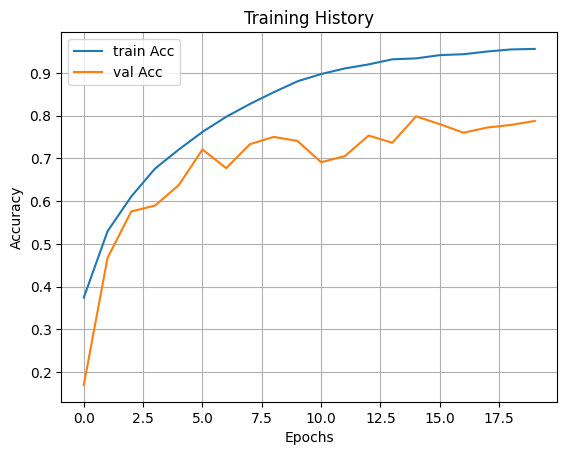

In [11]:
# plot training history

plt.plot(history.history["accuracy"] , label = "train Acc")

plt.plot(history.history["val_accuracy"] , label = "val Acc")
plt.title("Training History")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


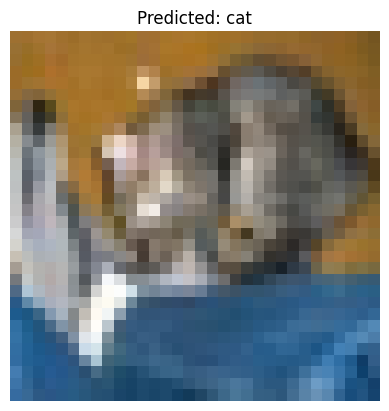

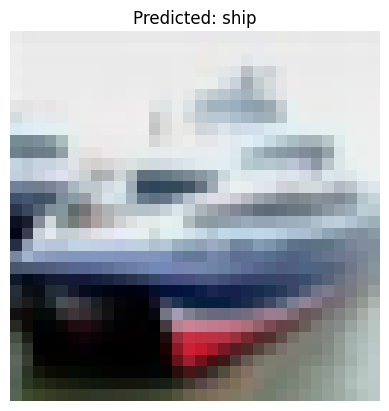

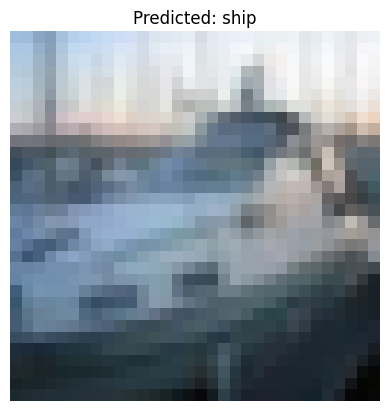

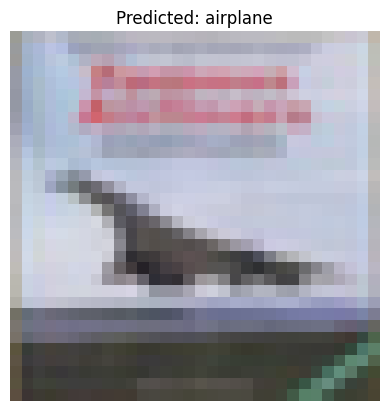

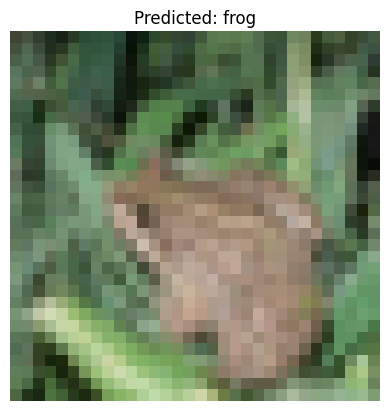

In [12]:
# inference(predict sample images )

class_names = ["airplane", 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']


preds = model.predict(x_test[:5])
for i, pred in enumerate(preds):
    plt.imshow(x_test[i])
    plt.title(f"Predicted: {class_names[np.argmax(pred)]}")
    plt.axis('off')
    plt.show()